# 02 - Feature Engineering & Baseline Modeling

**SECOM Semiconductor Fault Detection**

This notebook picks up from `01_eda.ipynb` and covers:

1. **Preprocessing** — load cleaned data, additional variance filtering, scaling
2. **Feature Engineering** — correlation filtering, mutual-information selection
3. **Class Imbalance** — documenting the ~14:1 pass/fail ratio and mitigation strategies
4. **Baseline Models** — Logistic Regression and Random Forest with evaluation

All reusable logic lives in `src/preprocess.py` and `src/features.py` — this notebook imports those modules and documents the reasoning behind each decision.

In [1]:
import sys
sys.path.insert(0, "..")

%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    ConfusionMatrixDisplay, 
    roc_auc_score, 
    RocCurveDisplay,
)

from src.preprocess import load_clean, run_preprocessing_pipeline, save_artifacts
from src.features import (
    get_feature_stats,
    drop_highly_correlated,
    select_top_k_by_mutual_info, 
    compute_balanced_weights,
    get_imbalance_summary,
)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams["figure.dpi"] = 120
pd.set_option("display.max_columns", 20)
print("Imports Loaded.")

Imports Loaded.


---
## Part 1 — Load Cleaned Data & Scale

### 1.1 Pick up From EDA

`01_eda.ipynb` saved `X_clean.csv` and `y.csv` to `data/processed/`.

That data already has:
— 4 features with >50% missing values **dropped**
— 140 zero-variance features **dropped**
— Remaining NaN values **median-imputed**

Starting shape: **1,567 samples × 446 features**

In [2]:
X_clean, y = load_clean(data_dir="../data/processed")

print(f"Loaded shape: {X_clean.shape}")
print(f"Any Nan? {X_clean.isnull().any().any() }")
print(f"Target distribution:\n{y.value_counts().sort_index().to_string()}")


Loaded shape: (1567, 446)
Any Nan? False
Target distribution:
label
0    1463
1     104


### 1.2 Additional Variance Filtering & Scaling

Even after EDA cleaning, some features may have near-zero variance (essentially constant
with rare exceptions). We apply a variance threshold, then standardize all features. 

The pipeline lives in `src/preprocess.py` so the same transforms can be reused 
at inference time via the FastAPI endpoint. 

In [3]:
# Pipeline: variance filter (threshold=0.0, i.e. constant-only) -> StandardScaler
X_processed, artifacts = run_preprocessing_pipeline(X_clean, variance_threshold=0.0)

print(f"\nProcessed shape: {X_processed.shape}")


Variance filter: dropped 0 features, kept 446

Processed shape: (1567, 446)


In [4]:
# Save fitted transformers for inference reproducibility
save_artifacts(artifacts, save_dir="../models/preprocessing")

Saved 2 preprocessing artifacts to ..\models\preprocessing


---
## Part 2 — Feature Engineering

### 2.1 Remove Highly Correlated Features

The EDA heatmap revealed sensor pairs wtih |r| > 0.9 — many sensors measure 
overlapping physical processes. We remove one from each pair where |r| > 0.95
to reduce multicollinearity without losing meaningful signal. 

In [5]:
X_decorr, dropped_corr = drop_highly_correlated(X_processed, threshold=0.95)


Correlation filter (|r| > 0.95): dropped 174 features, kept 272


### 2.2 Mutual Information Feature Selection

Pearson correlation only captures linear relationships. Mutual information (MI)
detects **non-linear dependencies** — important for sensor data where fault modes often involve threshold effects or interactions.

We welect the top 50 features by MI score as our modeling feature set. 

MI selection: kept top 50 of 272 features.


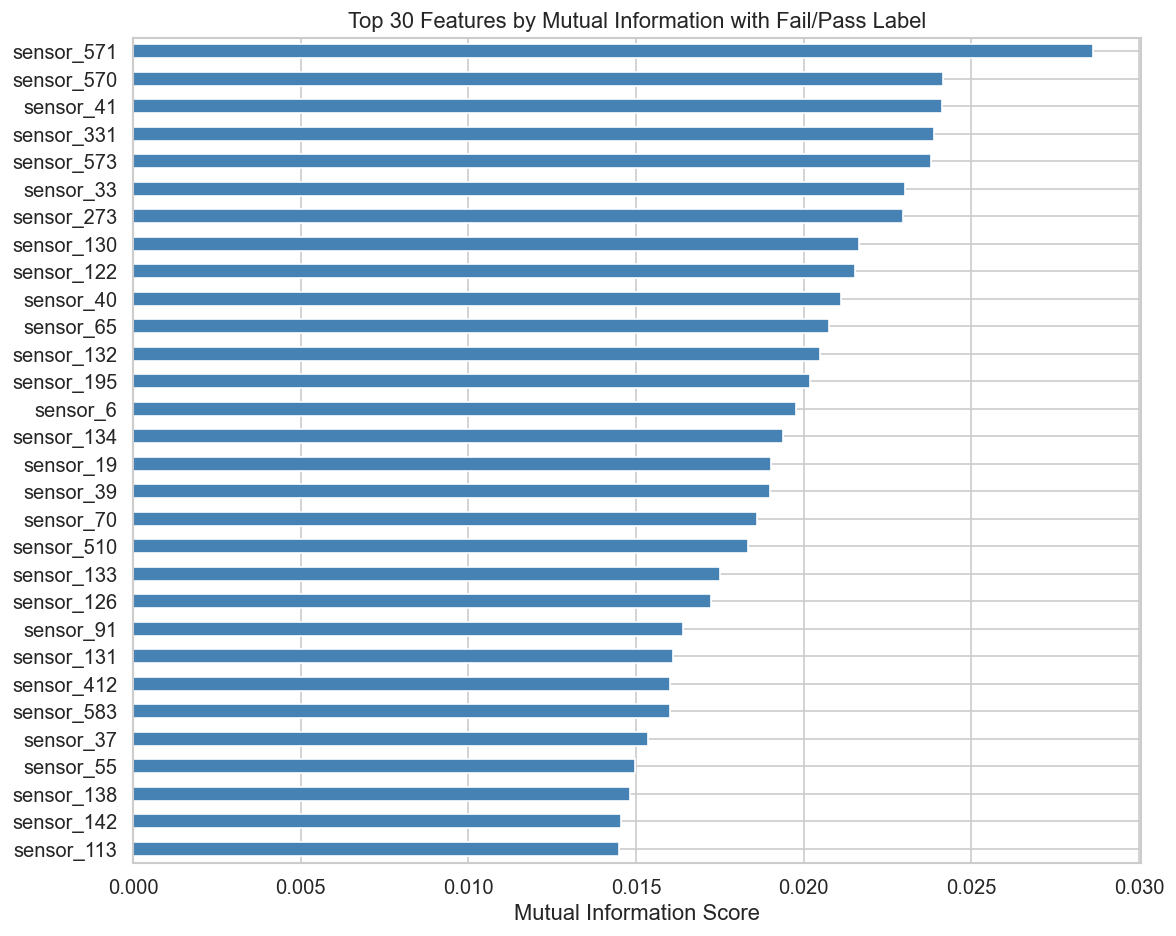

In [6]:
X_selected, mi_scores = select_top_k_by_mutual_info(X_decorr, y, k=50)

# Visualize MI scores — top 30
fig, ax = plt.subplots(figsize=(10, 8))
mi_scores.head(30).sort_values().plot.barh(ax=ax, color='steelblue')
ax.set_xlabel("Mutual Information Score")
ax.set_title("Top 30 Features by Mutual Information with Fail/Pass Label")
plt.tight_layout()
plt.show()

---
## Part 3 — Class Imbalance Analysis

## The Problem

SECOM has a ~14:1 pass-to-fail ratio. A naive model predicting "pass" every time
would achieve ~93% accuracy but **0% recall on failure** — completely useless for
fault detection where **missing a defect is far more costly than a false alarm**.

### Strategy: Class Weights vs. SMOTE 

| Approach | Pros | Cons |
| -------- | ---- | ---- |
| **Class Weights** | No synthetic data, preserves feature distributions, works natively in sklearn | Doesn't increase effective sample size |
| **SMOTE** | Increases minority class samples | Can generate unrealistic synthetic points in high-dim space; sensitive to noise features | 

**Decision: Use `class_weight='balanced'`** — it's cleaner for high-dimensional sensor data
and avoids the risk of SMOTE generating synthetic failure patterns in noisy feature regions.
We validate this choice by tracking recalll on the fail class below.

In [7]:
imbalance_summary = get_imbalance_summary(y)
class_weights = compute_balanced_weights(y)

Class Distribution Summary:
          count    pct
label                 
Pass (0)   1463  93.36
Fail (1)    104   6.64
Imbalance Ratio: 14.1 : 1
Class weights: {0: 0.5355434039644565, 1: 7.533653846153846}


--- 
## Part 4 — Baseline Models

### Train/Test Split

Stratified splitting preserves the class ratio in both sets. 
80/20 split with a fixed random seed for reproducibility. 

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} samples ({y_train.sum()} fails)")
print(f"Test: {X_test.shape[0]} samples ({y_test.sum()} fails)")

Train: 1253 samples (83 fails)
Test: 314 samples (21 fails)


### 4.1 Logistic Regression (Balanced)

A simple linear baseline. With `class_weight='balanced'`, sklearn automatically 
upweights the minority class (fail) inversely proportional to its frequency.

In [9]:
lr = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42,
    solver="liblinear",
)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

print("=== Logistic Regression (Balanced) ===")
print(classification_report(y_test, y_pred_lr, target_names=["Pass", "Fail"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.4f}")

=== Logistic Regression (Balanced) ===
              precision    recall  f1-score   support

        Pass       0.96      0.72      0.82       293
        Fail       0.13      0.57      0.21        21

    accuracy                           0.71       314
   macro avg       0.54      0.65      0.52       314
weighted avg       0.90      0.71      0.78       314

ROC-AUC: 0.6646


### 4.2 Random Forest (Balanced)

A non-linear baseline that can capture feature interactions. 
`class_weight='balanced'` applies the same inverse-frequency weighting.

In [10]:
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("=== Random Forest (Balanced) ===")
print(classification_report(y_test, y_pred_rf, target_names=["Pass", "Fail"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_rf):.4f}")

=== Random Forest (Balanced) ===
              precision    recall  f1-score   support

        Pass       0.94      1.00      0.97       293
        Fail       1.00      0.05      0.09        21

    accuracy                           0.94       314
   macro avg       0.97      0.52      0.53       314
weighted avg       0.94      0.94      0.91       314

ROC-AUC: 0.8038


### 4.3 Confusion Matrices

For fault detection, the key cell is **bottom-left (false negatives)** - 
these are actual failures the model missed. 

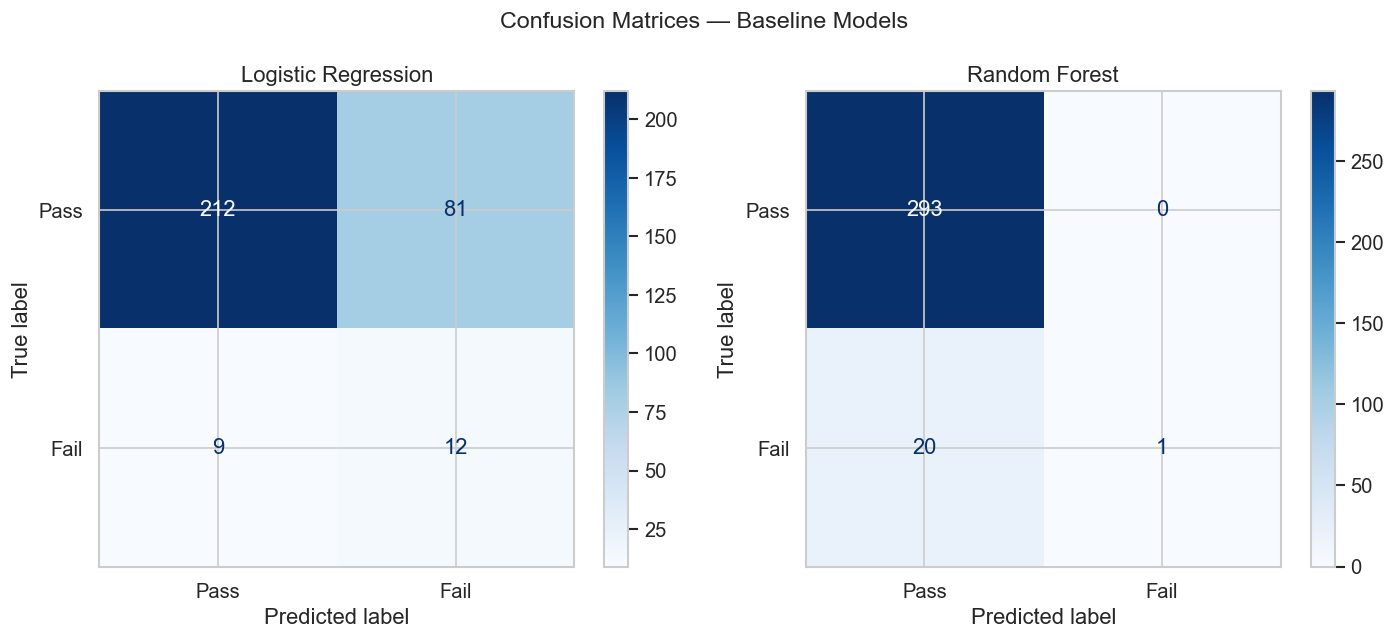

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_pred, title in zip(
    axes,
    [y_pred_lr, y_pred_rf],
    ["Logistic Regression", "Random Forest"],
):
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, display_labels=["Pass", "Fail"], ax=ax, cmap="Blues"
    )
    ax.set_title(title)

plt.suptitle("Confusion Matrices — Baseline Models", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 4.4 ROC Curves

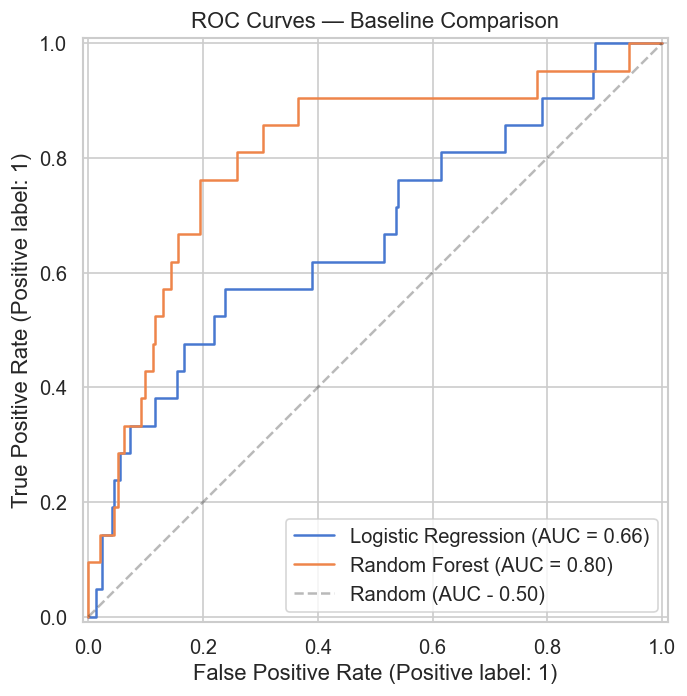

In [12]:
fig, ax = plt.subplots(figsize=(8,6))

RocCurveDisplay.from_predictions(y_test, y_prob_lr, name="Logistic Regression", ax=ax)
RocCurveDisplay.from_predictions(y_test, y_prob_rf, name="Random Forest", ax=ax)

ax.plot([0, 1], [0, 1], "k--", alpha=0.3, label="Random (AUC - 0.50)")
ax.set_title("ROC Curves — Baseline Comparison")
ax.legend()
plt.tight_layout()
plt.show()

### 4.5 Stratified Cross-Validation

A single train/test split can be noisy with only ~104 fail samples.
5-fold stratified CV gives a more robust performance estimate.

In [13]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "LogisticRegression": LogisticRegression(
        class_weight="balanced", max_iter=1000, solver="liblinear", random_state = 42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, class_weight="balanced", max_depth=10, 
        min_samples_leaf=5, random_state=42, n_jobs=1
    ),
}

print("5-Fold Stratified CV Results")
print("=" * 55)
for name, model in models.items():
    f1_scores = cross_val_score(model, X_selected, y, cv=cv, scoring="f1")
    recall_scores = cross_val_score(model, X_selected, y, cv=cv, scoring="recall")
    auc_scores = cross_val_score(model, X_selected, y, cv=cv, scoring="roc_auc")

    print(f"\n{name}:")
    print(f" F1(fail): {f1_scores.mean():.4f} ± {f1_scores.std():.4f}")
    print(f" Recall: {recall_scores.mean():.4f} ± {recall_scores.std():.4f}")
    print(f" ROC-AUC: {auc_scores.mean():.4f} ± {auc_scores.std():.4f}")

5-Fold Stratified CV Results

LogisticRegression:
 F1(fail): 0.2043 ± 0.0449
 Recall: 0.5390 ± 0.1279
 ROC-AUC: 0.6863 ± 0.0816

Random Forest:
 F1(fail): 0.0704 ± 0.0653
 Recall: 0.0386 ± 0.0358
 ROC-AUC: 0.7467 ± 0.0445


### 4.6 Random Forest Feature Importances

Which sensors matter most for predicting failures?
This preview sets up the SHAP analysis coming in a later notebook.

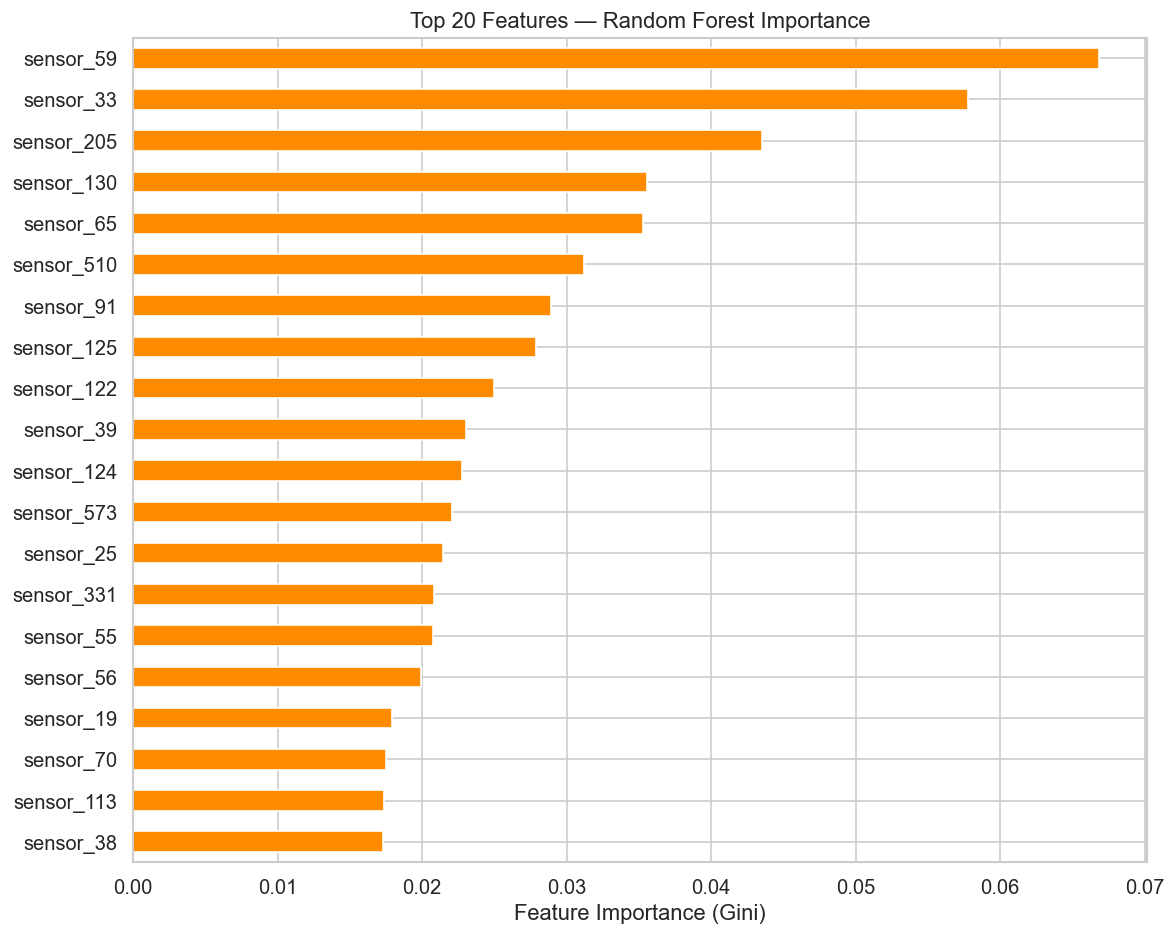

In [14]:
importances = pd.Series(rf.feature_importances_, index=X_selected.columns)
top_20 = importances.nlargest(20)

fig, ax = plt.subplots(figsize=(10, 8))
top_20.sort_values().plot.barh(ax=ax, color="darkorange")
ax.set_xlabel("Feature Importance (Gini)")
ax.set_title("Top 20 Features — Random Forest Importance")
plt.tight_layout()
plt.show()

---
## Summary & Next Steps

### What we built
- **Preprocessing pipeline** (`src/preprocess.py`) — variance filtering + StandardScaler on EDA-cleaned data
- **Feature Engineering** (`src/features.py`) — correlation filtering, MI selection, class weight computation
- **Baseline models** — Logistic Regression and Random Forest with balanced class weights

### Key Design Decisions
| Decision | Choice | Rationale | 
| -------- | ------ | --------- | 
| Imputation | Median (done in EDA) | Robust to outliers; KNN unreliable in 590-dim sparse space | 
| High-missing drop | >50% threshold (EDA) | 4 features removed |
| Zero-variance drop | std == 0 (EDA) | 140 constant features removed |
| Correlation filter | \|r\| > 0.95 | Remove near-duplicate sensors |
| Feature selection | Top 50 by MI | Captures non-linear dependencies | 
| Class imbalance | `class_weight='balanced'` | Cleaner than SMOTE for high-dim sensor data |

### Next Steps
- Multi-model comparison (Isolation Forest, LSTM Autoencoder)
- MLflow experiment tracking
- SHAP explainability
- FastAPI serving endpoint